### Libraries

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from typing import Tuple
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Normalize, Compose, Lambda

In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 6. Sieci neuronowe i regularyzacja

## Pierwszy model w PyTorch

Prosty przykład MLP (FCNN) dla problemu klasyfikacji (dane tabelaryczne).

Ładujemy przykładowe dane:

In [ ]:
print(load_breast_cancer().DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [ ]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_val, y_train, y_val= train_test_split(X, y, train_size=0.9)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

print("x values", [t.shape for t in [X_train, X_val, y_train, y_val]])
print("y values", torch.unique(y_train), torch.unique(y_val))


x values [torch.Size([512, 30]), torch.Size([57, 30]), torch.Size([512]), torch.Size([57])]
y values tensor([0., 1.]) tensor([0., 1.])


Przygotuj model z użyciem biblioteki PyTorch. Powienien zawierać  2 warstwy liniowe, funkcję aktywacji ReLu.

In [ ]:
class FCNN(nn.Module):
    def __init__(self):
        super(FCNN, self).__init__()
        self.linear1 = nn.Linear(...)
        self.linear2 = nn.Linear(...)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        y_pred = ...
        return y_pred

Epoch [1/50] Train Loss: 18.0587 Val Loss: 1.7179 Train Acc: 0.8125 Val Acc: 0.9298
Epoch [2/50] Train Loss: 10.4676 Val Loss: 0.9667 Train Acc: 0.9258 Val Acc: 0.9298
Epoch [3/50] Train Loss: 6.4452 Val Loss: 0.6230 Train Acc: 0.9453 Val Acc: 0.9298
Epoch [4/50] Train Loss: 4.6178 Val Loss: 0.4676 Train Acc: 0.9648 Val Acc: 0.9474
Epoch [5/50] Train Loss: 3.6874 Val Loss: 0.3881 Train Acc: 0.9746 Val Acc: 0.9474
Epoch [6/50] Train Loss: 3.0987 Val Loss: 0.3520 Train Acc: 0.9766 Val Acc: 0.9474
Epoch [7/50] Train Loss: 2.7302 Val Loss: 0.3229 Train Acc: 0.9863 Val Acc: 0.9649
Epoch [8/50] Train Loss: 2.4619 Val Loss: 0.3147 Train Acc: 0.9863 Val Acc: 0.9649
Epoch [9/50] Train Loss: 2.2587 Val Loss: 0.2969 Train Acc: 0.9863 Val Acc: 0.9825
Epoch [10/50] Train Loss: 2.1177 Val Loss: 0.2923 Train Acc: 0.9863 Val Acc: 0.9825
Epoch [11/50] Train Loss: 2.0001 Val Loss: 0.2787 Train Acc: 0.9863 Val Acc: 0.9825
Epoch [12/50] Train Loss: 1.8878 Val Loss: 0.2780 Train Acc: 0.9883 Val Acc: 0.9825

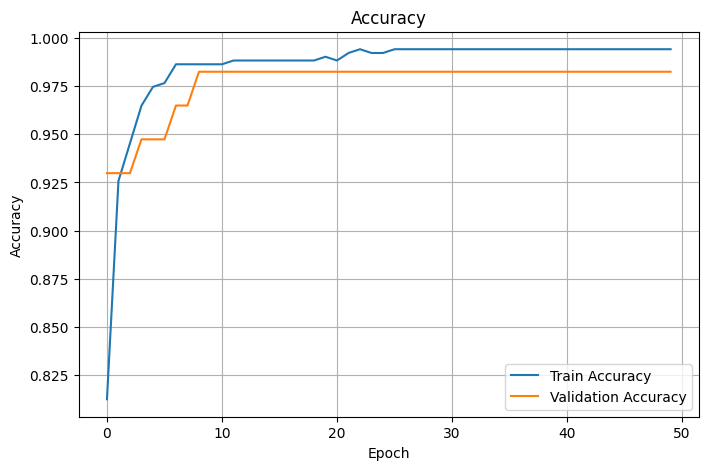

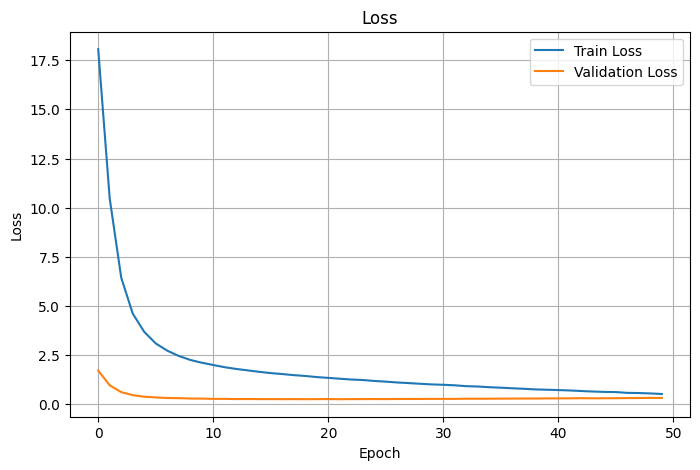

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FCNN().to(device)

criterion = .. # BCE
optimizer = ... # Adam

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=...., shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=....)


train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []

epochs = 50

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_preds = []
    train_labels = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).view(-1, 1)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        probs = torch.sigmoid(logits)
        preds = ... # zamien na klasy
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(y_batch.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)

    model.eval()

    val_loss = 0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).view(-1, 1)

            logits = model(X_batch)

            loss = criterion(logits, y_batch)

            val_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = ...

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

plt.figure(figsize=(8, 5))
plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid()

plt.show()

## Większy model - MNIST

MNIST jest popularnym datasetem, na którym można testować modele, zawiera ręcznie rysowane cyfry (10 klas).

Obrazy zazwyczaj przetwarza się za pomocą sieci konwolucyjnych, jednak proste problemy można spórbować rozwiązać z użyciem warstw liniowych.

In [ ]:
def calculate_mean_and_std() -> Tuple[float, float]:
    train_data = MNIST(root='.', download=True, train=True, transform=ToTensor())
    mean = (train_data.data.type(torch.float32) / 255).mean().item()
    std = (train_data.data.type(torch.float32) / 255).std().item()
    return mean, std

mean, std = calculate_mean_and_std()

train_data = MNIST(root='.',
                   download=True,
                   train=True,
                   transform=Compose([ToTensor(),
                                      Normalize((mean,), (std,)),
                                      Lambda(lambda x: x.view(-1))]))

test_data = MNIST(root='.',
                  download=True,
                  train=False,
                  transform=Compose([ToTensor(),
                                     Normalize((mean,), (std,)),
                                     Lambda(lambda x: x.view(-1))]))


Napisz sieć zbudowaną z 3 warstw.

In [ ]:
class MnistNN(nn.Module):
    def __init__(self):
        super(MnistNN, self).__init__()

        ...

    def forward(self, x):

        x = x.view(x.size(0), -1)

         ...

        return y_pred


Epoch [1/20] Train Loss: 213.7334 Test Loss: 18.1599 Train Acc: 0.9310 Test Acc: 0.9621
Epoch [2/20] Train Loss: 88.0457 Test Loss: 14.1565 Train Acc: 0.9709 Test Acc: 0.9710
Epoch [3/20] Train Loss: 61.4190 Test Loss: 13.3239 Train Acc: 0.9793 Test Acc: 0.9745
Epoch [4/20] Train Loss: 46.2422 Test Loss: 11.7769 Train Acc: 0.9846 Test Acc: 0.9790
Epoch [5/20] Train Loss: 36.4417 Test Loss: 14.3358 Train Acc: 0.9876 Test Acc: 0.9740
Epoch [6/20] Train Loss: 29.8882 Test Loss: 12.6780 Train Acc: 0.9899 Test Acc: 0.9772
Epoch [7/20] Train Loss: 27.3173 Test Loss: 11.5205 Train Acc: 0.9900 Test Acc: 0.9805
Epoch [8/20] Train Loss: 24.1703 Test Loss: 11.4571 Train Acc: 0.9916 Test Acc: 0.9820
Epoch [9/20] Train Loss: 19.6329 Test Loss: 13.6330 Train Acc: 0.9930 Test Acc: 0.9796
Epoch [10/20] Train Loss: 20.6304 Test Loss: 14.2363 Train Acc: 0.9929 Test Acc: 0.9809
Epoch [11/20] Train Loss: 16.5196 Test Loss: 15.9458 Train Acc: 0.9943 Test Acc: 0.9763
Epoch [12/20] Train Loss: 14.5847 Test L

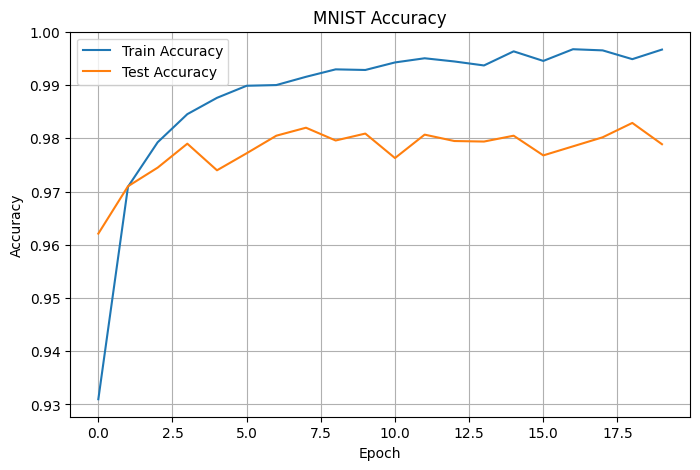

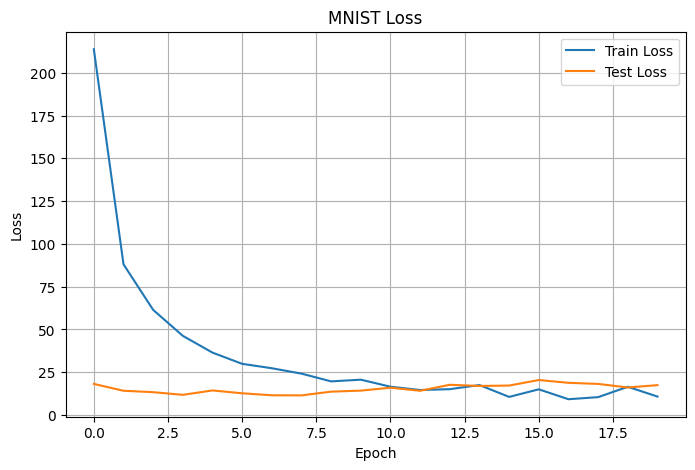

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MnistNN().to(device)

criterion = # CrossEntropy

optimizer = ... # Adam

train_loader = DataLoader(train_data, batch_size=...., shuffle=True)
test_loader = DataLoader(test_data, batch_size=....)

train_acc_history = []
test_acc_history = []

train_loss_history = []
test_loss_history = []

epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0

    train_preds = []
    train_labels = []

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(y_batch.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)


    model.eval()

    test_loss = 0
    test_preds = []
    test_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            test_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(y_batch.cpu().numpy())

    test_acc = accuracy_score(test_labels, test_preds)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Test Loss: {test_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Test Acc: {test_acc:.4f}"
    )

plt.figure(figsize=(8, 5))

plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(test_acc_history, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MNIST Accuracy")

plt.legend()
plt.grid()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(train_loss_history, label="Train Loss")
plt.plot(test_loss_history, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST Loss")

plt.legend()
plt.grid()

plt.show()

Dodaj do modelu dropout i batch normalization.

In [ ]:
class MnistNNReg(nn.Module):
    def __init__(self):
        super(MnistNNReg, self).__init__()

        ...
        self.dropout = nn.Dropout(...)
        self.batch = nn.BatchNorm1d(...)

    def forward(self, x):

        x = x.view(x.size(0), -1)
        ...
        return y_pred

Epoch [1/20] Train Loss: 212.4230 Test Loss: 15.0417 Train Acc: 0.9358 Test Acc: 0.9697
Epoch [2/20] Train Loss: 90.3515 Test Loss: 11.4927 Train Acc: 0.9702 Test Acc: 0.9755
Epoch [3/20] Train Loss: 66.8926 Test Loss: 10.0246 Train Acc: 0.9776 Test Acc: 0.9799
Epoch [4/20] Train Loss: 54.4800 Test Loss: 12.7842 Train Acc: 0.9809 Test Acc: 0.9739
Epoch [5/20] Train Loss: 46.4213 Test Loss: 9.6305 Train Acc: 0.9840 Test Acc: 0.9810
Epoch [6/20] Train Loss: 41.3883 Test Loss: 10.3479 Train Acc: 0.9853 Test Acc: 0.9788
Epoch [7/20] Train Loss: 33.7603 Test Loss: 9.1352 Train Acc: 0.9879 Test Acc: 0.9824
Epoch [8/20] Train Loss: 30.4579 Test Loss: 9.3732 Train Acc: 0.9890 Test Acc: 0.9811
Epoch [9/20] Train Loss: 27.2935 Test Loss: 10.0494 Train Acc: 0.9902 Test Acc: 0.9809
Epoch [10/20] Train Loss: 24.9288 Test Loss: 10.4151 Train Acc: 0.9907 Test Acc: 0.9812
Epoch [11/20] Train Loss: 21.6100 Test Loss: 9.4650 Train Acc: 0.9921 Test Acc: 0.9818
Epoch [12/20] Train Loss: 21.4320 Test Loss:

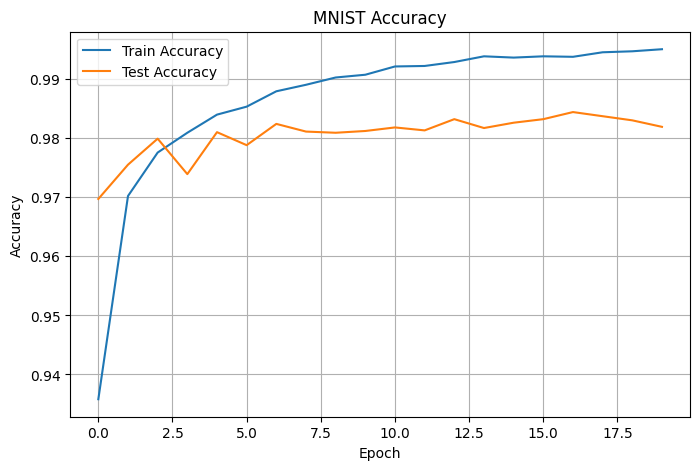

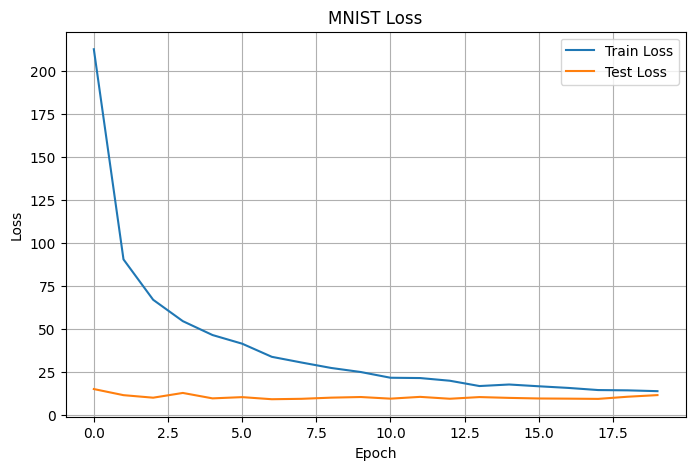

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MnistNNReg().to(device)

criterion = ...

optimizer = ...

train_loader = DataLoader(train_data, batch_size=..., shuffle=True)
test_loader = DataLoader(test_data, batch_size=...)

train_acc_history = []
test_acc_history = []

train_loss_history = []
test_loss_history = []

epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0

    train_preds = []
    train_labels = []

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(y_batch.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)


    model.eval()

    test_loss = 0
    test_preds = []
    test_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            test_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(y_batch.cpu().numpy())

    test_acc = accuracy_score(test_labels, test_preds)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Test Loss: {test_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Test Acc: {test_acc:.4f}"
    )

plt.figure(figsize=(8, 5))

plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(test_acc_history, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MNIST Accuracy")

plt.legend()
plt.grid()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(train_loss_history, label="Train Loss")
plt.plot(test_loss_history, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST Loss")

plt.legend()
plt.grid()

plt.show()